# Regresión lineal — grid de ventanas temporales

Evaluamos regresión lineal multivariante para todas las combinaciones de:
- **Ventana de entrada**: 5, 10, 30, 90 días
- **Ventana de salida**: 1, 5, 30, 90 días

Métrica: **MAE** (Mean Absolute Error) calculado sobre **train** y **test** (últimos 10% de la serie, sin shuffle). Comparar ambos sirve para detectar overfitting.

In [1]:
import sys
import mlflow
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

EXPERIMENT_NAME = "Regresion_Lineal"
mlflow.set_experiment(EXPERIMENT_NAME)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

from util import get_train_test

/opt/homebrew/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Configuración del grid

In [2]:
input_windows = [5, 10, 30, 90]
output_windows = [1, 5, 30, 90]

## Entrenamiento y evaluación

Para cada combinación:
1. Generamos X, y con `get_train_test` (los retornos se cargan una sola vez gracias al caché).
2. Aplanamos X de `(n, input_w, features)` a `(n, input_w * features)` para sklearn.
3. Ajustamos un `LinearRegression` multi-output y calculamos MAE sobre **train** y **test**.

In [8]:
results = []

for in_w in input_windows:
    for out_w in output_windows:
        run_name = f"{EXPERIMENT_NAME}_input{in_w}_output{out_w}"
        #Si ya existe un run con el mismo nombre, lo eliminamos para evitar conflictos
        existing_runs = mlflow.search_runs(filter_string=f'tags.mlflow.runName = "{run_name}"')
        if not existing_runs.empty:
            mlflow.delete_run(existing_runs.iloc[0].run_id)
        with mlflow.start_run(run_name=run_name):
            d = get_train_test(input_window_size=in_w, output_window_size=out_w)

            X_tr = d.X_train.reshape(d.X_train.shape[0], -1)
            X_te = d.X_test.reshape(d.X_test.shape[0], -1)

            #Reservamos el 10% de los datos de entrenamiento para validación, de cara a ser más comparables con los modelos de redes neuronales que entrenaremos posteriormente
            val_size = int(0.10 * X_tr.shape[0])
            X_val = X_tr[-val_size:]
            y_val = d.y_train[-val_size:]
            X_tr = X_tr[:-val_size]
            y_tr = d.y_train[:-val_size]

            model = LinearRegression()
            model.fit(X_tr, y_tr)

            y_pred_tr = model.predict(X_tr)
            y_pred_val = model.predict(X_val)
            y_pred_te = model.predict(X_te)

            mae_tr = mean_absolute_error(y_tr, y_pred_tr)
            val_mae = mean_absolute_error(y_val, y_pred_val)
            mae_te = mean_absolute_error(d.y_test, y_pred_te)

            #Registramos los parametros y métricas en MLflow
            mlflow.log_param("model_type", "LinearRegression")
            mlflow.log_param("input_window_size", in_w)
            mlflow.log_param("output_window_size", out_w)
            mlflow.log_param("num_features", d.X_train.shape[2])
            mlflow.log_param("num_samples", X_tr.shape[0])

            mlflow.log_metric("train_mae", mae_tr)
            mlflow.log_metric("val_mae", val_mae)
            mlflow.log_metric("test_mae", mae_te)

            # Registramos el modelo entrenado en MLflow
            mlflow.sklearn.log_model(model, name="linear_regression_model")

            results.append({
                "input_window": in_w,
                "output_window": out_w,
                "MAE_train": mae_tr,
                "MAE_test": mae_te,
            })
            print(f"input={in_w:>3}d, output={out_w:>3}d  ->  MAE train = {mae_tr:.6f} | MAE test = {mae_te:.6f}")

results_df = pd.DataFrame(results)
results_df

2026/04/26 17:53:42 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/04/26 17:53:43 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


input=  5d, output=  1d  ->  MAE train = 0.011821 | MAE test = 0.012384


2026/04/26 17:53:44 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


input=  5d, output=  5d  ->  MAE train = 0.005440 | MAE test = 0.005625


2026/04/26 17:53:45 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


...

2026/04/26 17:54:03 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


input= 90d, output= 30d  ->  MAE train = 0.002027 | MAE test = 0.002628


2026/04/26 17:54:05 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


input= 90d, output= 90d  ->  MAE train = 0.001157 | MAE test = 0.001518


,input_window,output_window,MAE_train,MAE_test
0,5,1,0.011821,0.012384
1,5,5,0.005440,0.005625
2,5,30,0.002192,0.002340
3,5,90,0.001263,0.001271
4,10,1,0.011796,0.012554
5,10,5,0.005418,0.005698
6,10,30,0.002181,0.002358
7,10,90,0.001258,0.001282
8,30,1,0.011676,0.012924
9,30,5,0.005337,0.005877


## Matrices de MAE (train y test)

In [4]:
mae_train_matrix = results_df.pivot(index="input_window", columns="output_window", values="MAE_train")
mae_test_matrix  = results_df.pivot(index="input_window", columns="output_window", values="MAE_test")

print("MAE — TRAIN")
display(mae_train_matrix)

print("MAE — TEST")
display(mae_test_matrix)

print("Gap (test - train) — cuanto mayor, más overfitting")
display(mae_test_matrix - mae_train_matrix)

MAE — TRAIN


output_window,1,5,30,90
input_window,,,,
5,0.011821,0.005440,0.002192,0.001263
10,0.011796,0.005418,0.002181,0.001258
30,0.011676,0.005337,0.002148,0.001235
90,0.011191,0.005100,0.002027,0.001157


MAE — TEST


output_window,1,5,30,90
input_window,,,,
5,0.012384,0.005625,0.002340,0.001271
10,0.012554,0.005698,0.002358,0.001282
30,0.012924,0.005877,0.002436,0.001351
90,0.014095,0.006348,0.002628,0.001518


Gap (test - train) — cuanto mayor, más overfitting


output_window,1,5,30,90
input_window,,,,
5,0.000563,0.000184,0.000148,0.000009
10,0.000759,0.000280,0.000177,0.000024
30,0.001248,0.000539,0.000288,0.000116
90,0.002904,0.001248,0.000602,0.000361


## Heatmap

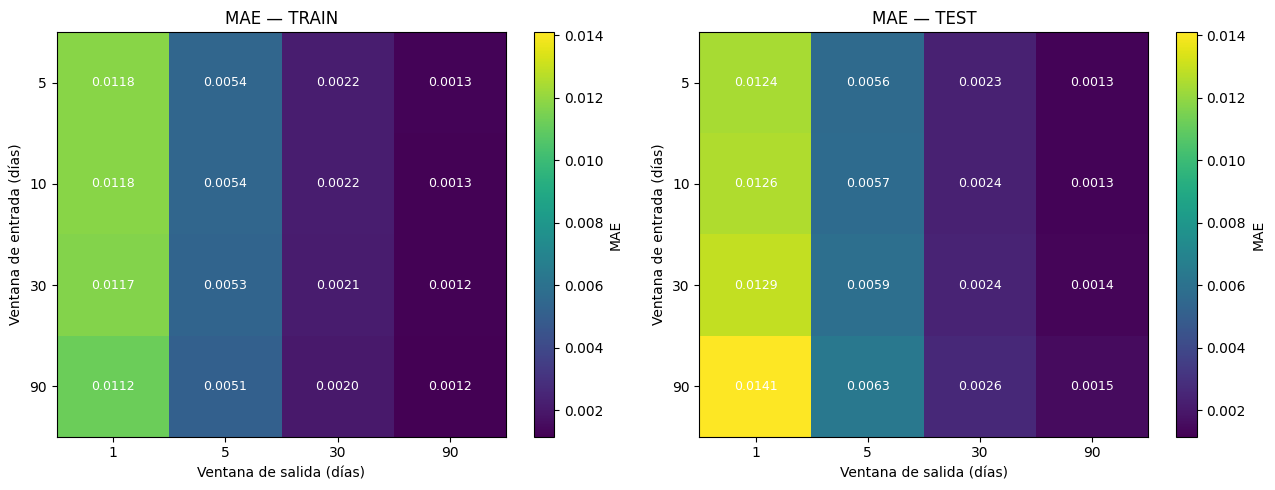

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Misma escala de color para que sean directamente comparables
vmin = min(mae_train_matrix.values.min(), mae_test_matrix.values.min())
vmax = max(mae_train_matrix.values.max(), mae_test_matrix.values.max())

for ax, matrix, title in [
    (axes[0], mae_train_matrix, "MAE — TRAIN"),
    (axes[1], mae_test_matrix, "MAE — TEST"),
]:
    im = ax.imshow(matrix.values, cmap="viridis", aspect="auto", vmin=vmin, vmax=vmax)
    ax.set_xticks(range(len(matrix.columns)))
    ax.set_xticklabels(matrix.columns)
    ax.set_yticks(range(len(matrix.index)))
    ax.set_yticklabels(matrix.index)
    ax.set_xlabel("Ventana de salida (días)")
    ax.set_ylabel("Ventana de entrada (días)")
    ax.set_title(title)
    for i in range(matrix.shape[0]):
        for j in range(matrix.shape[1]):
            ax.text(j, i, f"{matrix.values[i, j]:.4f}",
                    ha="center", va="center", color="white", fontsize=9)
    plt.colorbar(im, ax=ax, label="MAE")

plt.tight_layout()
plt.show()

## Mejor combinación

In [6]:
best = results_df.loc[results_df["MAE_test"].idxmin()]
print(f"Mejor combinación (por MAE test): input={int(best.input_window)}d, output={int(best.output_window)}d")
print(f"MAE train: {best.MAE_train:.6f}")
print(f"MAE test:  {best.MAE_test:.6f}")

Mejor combinación (por MAE test): input=5d, output=90d
MAE train: 0.001263
MAE test:  0.001271


## Guardar como benchmark

Guardamos los MAE del grid como benchmark de referencia. El resto de notebooks (MLP, RNN, etc.) se comparan contra este CSV usando `compare_to_benchmark()` y `plot_benchmark_comparison()` de `util.py`.

In [7]:
from util import save_benchmark

path = save_benchmark(results_df, "lr_benchmark")
print(f"Benchmark guardado en: {path}")

Benchmark guardado en: /Users/higiniopaternaortiz/Master_BME/Neural-Networks-Forecasting/data/lr_benchmark.csv
